In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np, json
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.strategies.mpt import (
    RISK_FREE, TRADING_DAYS, expected_return_and_risk, max_sharpe_weights, mpt_window_strategy
)
from tradinglab.strategies.sma import sma_crossover_weights
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.metrics import total_return, max_drawdown, volatility
from tradinglab.report import report

os.makedirs('dashboard/data', exist_ok=True)

feed = DataFeed.from_dir('data/egx')
split = int(feed.n_days * 0.7)
sim = PortfolioSimulator(feed)

print(f'universe: {feed.n_assets} stocks | {feed.n_days} days | test starts at day {split}')

universe: 34 stocks | 1159 days | test starts at day 811


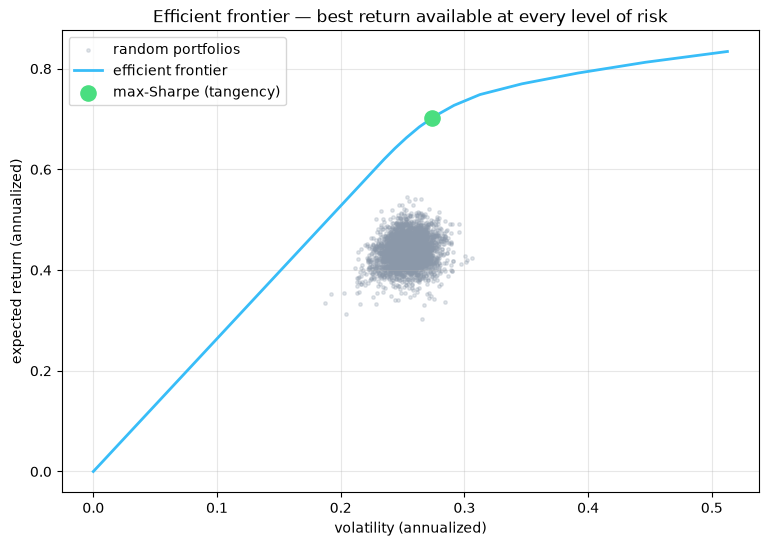

max-Sharpe portfolio: expected return 70.3%, volatility 27.4%, Sharpe 1.57
top holdings: {'SWDY': np.float64(0.226), 'DOMTY': np.float64(0.189), 'JUFO': np.float64(0.177), 'ARCC': np.float64(0.148), 'TMGH': np.float64(0.105)}


In [2]:
train_returns = feed.returns[:split]
mu = train_returns.mean(axis=0) * TRADING_DAYS
Sigma = np.cov(train_returns, rowvar=False) * TRADING_DAYS

def efficient_frontier(mu, Sigma, n_points=40):
    from scipy.optimize import minimize
    n = len(mu)
    target_returns = np.linspace(mu.min(), mu.max(), n_points)
    frontier_risk, frontier_ret = [], []
    for target in target_returns:
        constraints = [
            {"type": "eq", "fun": lambda w: w.sum() - 1.0},
            {"type": "eq", "fun": lambda w, target=target: w @ mu - target},
        ]
        bounds = [(0.0, 1.0)] * n
        x0 = np.ones(n) / n
        res = minimize(lambda w: w @ Sigma @ w, x0, method="SLSQP", bounds=bounds, constraints=constraints)
        if res.success:
            frontier_ret.append(target)
            frontier_risk.append(np.sqrt(max(res.fun, 0)))
    return np.array(frontier_risk), np.array(frontier_ret)

frontier_risk, frontier_ret = efficient_frontier(mu, Sigma)

rng = np.random.default_rng(0)
random_w = rng.dirichlet(np.ones(len(mu)), size=3000)
random_ret = random_w @ mu
random_risk = np.sqrt(np.einsum('ij,jk,ik->i', random_w, Sigma, random_w))

w_tangency = max_sharpe_weights(mu, Sigma, RISK_FREE)
tangency_ret, tangency_risk = expected_return_and_risk(w_tangency, mu, Sigma)

plt.figure(figsize=(9, 6))
plt.scatter(random_risk, random_ret, s=6, alpha=0.25, color='#8b98a9', label='random portfolios')
plt.plot(frontier_risk, frontier_ret, color='#38bdf8', linewidth=2, label='efficient frontier')
plt.scatter([tangency_risk], [tangency_ret], color='#4ade80', s=120, zorder=5, label='max-Sharpe (tangency)')
plt.xlabel('volatility (annualized)'); plt.ylabel('expected return (annualized)')
plt.legend(); plt.grid(alpha=0.3); plt.title('Efficient frontier — best return available at every level of risk')
plt.show()

print(f'max-Sharpe portfolio: expected return {tangency_ret:.1%}, volatility {tangency_risk:.1%}, '
      f'Sharpe {(tangency_ret - RISK_FREE) / tangency_risk:.2f}')
print('top holdings:', {feed.symbols[i]: round(w_tangency[i], 3) for i in np.argsort(-w_tangency)[:5]})

c:\Users\youse\Documents\2026-orion\src\tradinglab\features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


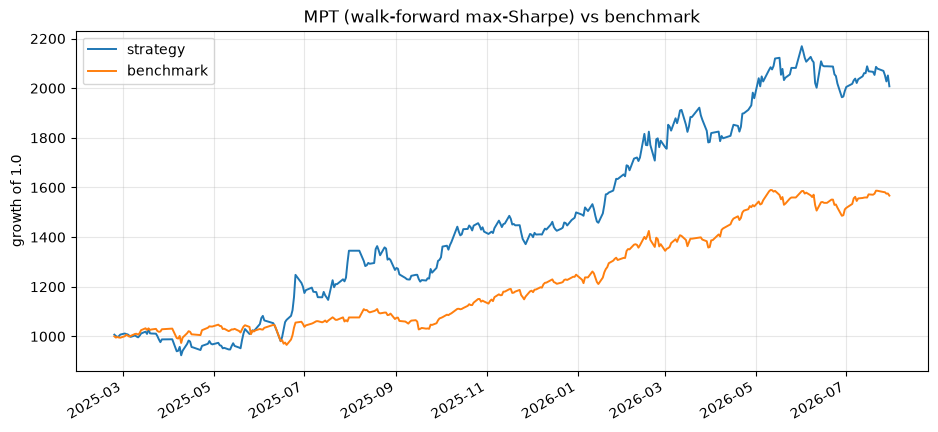

total return   : +100.8%
sharpe         : 2.02
max drawdown   : 10.5%
final value    : 2007.69   (benchmark 1567.20)
beat benchmark : YES
                 you beat the benchmark by 440 EGP


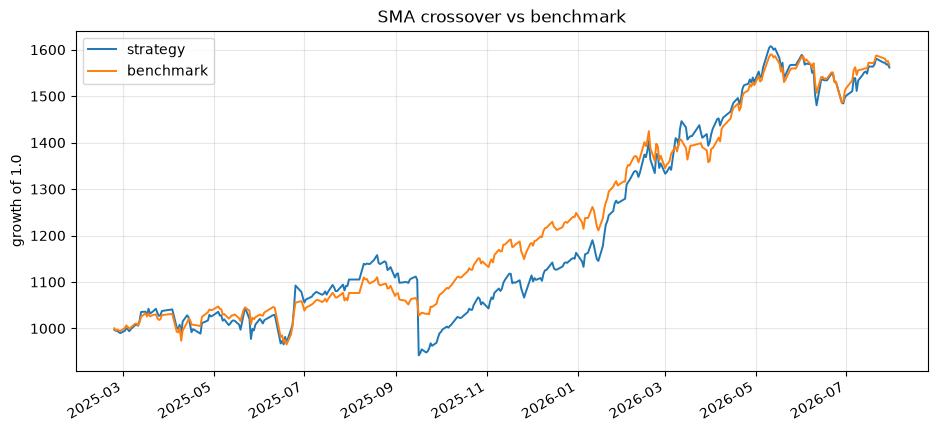

total return   : +56.2%
sharpe         : 1.55
max drawdown   : 18.6%
final value    : 1561.69   (benchmark 1567.20)
beat benchmark : no
                 you lost to the benchmark by 6 EGP


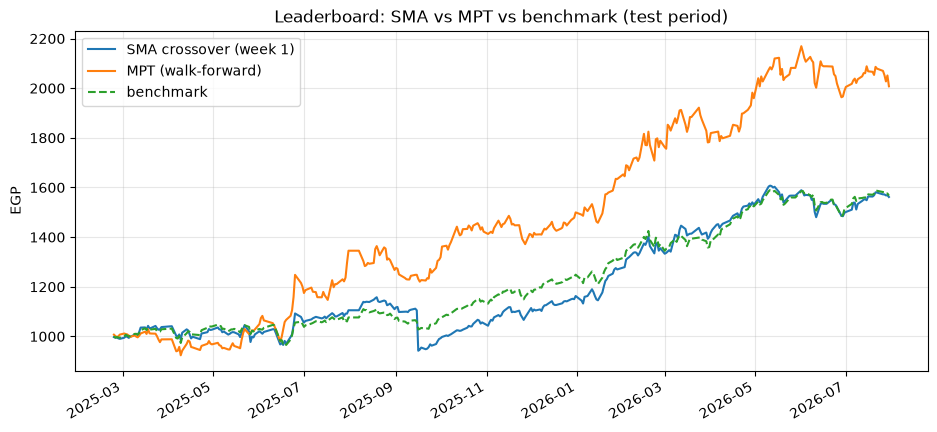

SMA final: 1,562 EGP
MPT final: 2,008 EGP
benchmark: 1,567 EGP


In [3]:
result_mpt = run_backtest(sim, lambda o: mpt_window_strategy(o, RISK_FREE), lookback=60, start=split)
result_sma = run_backtest(sim, lambda o: sma_crossover_weights(o, 9, 20), lookback=30, start=split)

report(result_mpt, title='MPT (walk-forward max-Sharpe) vs benchmark', start_capital=1000.0)
report(result_sma, title='SMA crossover vs benchmark', start_capital=1000.0)

START = 1000.0
dates = result_mpt['dates']
plt.figure(figsize=(11, 5))
plt.plot(dates, result_sma['portfolio'] * START, label='SMA crossover (week 1)')
plt.plot(dates, result_mpt['portfolio'] * START, label='MPT (walk-forward)')
plt.plot(dates, result_mpt['benchmark'] * START, label='benchmark', linestyle='--')
plt.legend(); plt.grid(alpha=0.3); plt.ylabel('EGP')
plt.title('Leaderboard: SMA vs MPT vs benchmark (test period)')
plt.gcf().autofmt_xdate(); plt.show()

print(f"SMA final: {result_sma['portfolio'][-1]*START:,.0f} EGP")
print(f"MPT final: {result_mpt['portfolio'][-1]*START:,.0f} EGP")
print(f"benchmark: {result_mpt['benchmark'][-1]*START:,.0f} EGP")

In [5]:
sma_returns = result_sma['portfolio_returns']
mpt_returns = result_mpt['portfolio_returns']
bench_returns = result_mpt['benchmark'][1:] / result_mpt['benchmark'][:-1] - 1.0

risk_table = {
    'sma': {
        'volatility_pct': volatility(sma_returns) * 100,
        'max_drawdown_pct': max_drawdown(sma_returns) * 100,
        'total_return_pct': total_return(sma_returns) * 100,
        'final_value': float(result_sma['portfolio'][-1] * START),
    },
    'mpt': {
        'volatility_pct': volatility(mpt_returns) * 100,
        'max_drawdown_pct': max_drawdown(mpt_returns) * 100,
        'total_return_pct': total_return(mpt_returns) * 100,
        'final_value': float(result_mpt['portfolio'][-1] * START),
    },
    'benchmark': {
        'volatility_pct': volatility(bench_returns) * 100,
        'max_drawdown_pct': max_drawdown(bench_returns) * 100,
        'total_return_pct': total_return(bench_returns) * 100,
        'final_value': float(result_mpt['benchmark'][-1] * START),
    },
}

for name, stats in risk_table.items():
    print(f"{name:10s} | return {stats['total_return_pct']:+7.2f}% | vol {stats['volatility_pct']:6.2f}% "
          f"| max dd {stats['max_drawdown_pct']:6.2f}% | final {stats['final_value']:,.0f} EGP")

leaderboard_data = {
    'dates': [str(d)[:10] for d in dates],
    'sma': [round(x, 4) for x in (result_sma['portfolio'] * START).tolist()],
    'mpt': [round(x, 4) for x in (result_mpt['portfolio'] * START).tolist()],
    'benchmark': [round(x, 4) for x in (result_mpt['benchmark'] * START).tolist()],
    'risk': risk_table,
}
json.dump(leaderboard_data, open('dashboard/data/leaderboard.json', 'w'), indent=2)
print('\nsaved dashboard/data/leaderboard.json')

sma        | return  +56.17% | vol  22.54% | max dd  18.62% | final 1,562 EGP
mpt        | return +100.77% | vol  26.86% | max dd  10.50% | final 2,008 EGP
benchmark  | return  +56.68% | vol  15.93% | max dd   7.80% | final 1,567 EGP

saved dashboard/data/leaderboard.json
